In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score,accuracy_score
from imblearn.combine import SMOTETomek
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load data
df = pd.read_csv('./american_bankruptcy.csv')
df.head()


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


1. Company Name (This column can be dropped)
2. Status: Company Status (Target Column)
3. Year: (1999 - 2018)
4. Current assets: All the assets of a company that are expected to be sold or used as a result of standard business
5. Cost of goods sold: The total amount a company paid as a cost directly related to the sale of products
6. Depreciation and amortization: Depreciation refers to the loss of value of a tangible fixed asset over
7. EBITDA: Earnings before interest, taxes, depreciation, and amortization. A measure of a company’s overall
8. Inventory: The accounting of items and raw materials that a company either uses in production or sells
9. Net Income: The overall profitability of a company after all expenses and costs have been deducted from total
10. Total Receivables: The balance of money due to a firm for goods or services delivered or used but not yet paid for
11. Market Value: The price of an asset in a marketplace. In our dataset, it refers to the market capitalization
12. Net Sales: The sum of a company’s gross sales minus its returns, allowances, and discounts
13. Total Assets: All the assets, or items of value, a business owns
14. Total Long-term Debt: A company’s loans and other liabilities that will not become due within one year of the balance
15. EBIT: Earnings before interest and taxes
16. Gross Profit: The profit a business makes after subtracting all the costs that are related to manufacturing and
17. Total Current Liabilities: The sum of accounts payable, accrued liabilities, and taxes such as bonds payable at the
18. Retained Earnings: The amount of profit a company has left over after paying all its direct costs, indirect costs
19. Total Revenue: The amount of income that a business has made from all sales before subtracting expenses
20. Total Liabilities: The combined debts and obligations that the company owes to outside parties
21. Total Operating Expenses: The expense a business incurs through its normal business operations


In [7]:
df.rename(columns={"status_label" : "Company Status","X1" : "Current assets","X2": "Cost of goods sold",
                   "X3" : "Depreciation and amortization","X4": "EBDITDA","X5" : "Inventory","X6" : "Net Income",
                   "X7" : "Total Receivable","X8" : "Market Value","X9" : "Net Sales","X10" : "Total Assets",
                   "X11" : "Total Long-term Debt","X12" : "EBIT" ,"X13" : "Gross Profit",
                   "X14" : "Total Current Liabilitie","X15" : "Retained Earnings" , "X16" :"Total Revenue",
                   "X17" : "Total Liabilities", "X18" : "Total Operating Expenses"},inplace= True)

# EDA

In [5]:
df.shape

(78682, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company_name                   78682 non-null  object 
 1   Company Status                 78682 non-null  object 
 2   year                           78682 non-null  int64  
 3   Current assets                 78682 non-null  float64
 4   Cost of goods sold             78682 non-null  float64
 5   Depreciation and amortization  78682 non-null  float64
 6   EBDITDA                        78682 non-null  float64
 7   Inventory                      78682 non-null  float64
 8   Net Income                     78682 non-null  float64
 9   Total Receivable               78682 non-null  float64
 10  Market Value                   78682 non-null  float64
 11  Net Sales                      78682 non-null  float64
 12  Total Assets                   78682 non-null 

In [7]:
# checking for null values
df.isnull().sum()

company_name                     0
Company Status                   0
year                             0
Current assets                   0
Cost of goods sold               0
Depreciation and amortization    0
EBDITDA                          0
Inventory                        0
Net Income                       0
Total Receivable                 0
Market Value                     0
Net Sales                        0
Total Assets                     0
Total Long-term Debt             0
EBIT                             0
Gross Profit                     0
Total Current Liabilitie         0
Retained Earnings                0
Total Revenue                    0
Total Liabilities                0
Total Operating Expenses         0
dtype: int64

In [8]:
df.describe()

,year,Current assets,Cost of goods sold,Depreciation and amortization,EBDITDA,Inventory,Net Income,Total Receivable,Market Value,Net Sales,Total Assets,Total Long-term Debt,EBIT,Gross Profit,Total Current Liabilitie,Retained Earnings,Total Revenue,Total Liabilities,Total Operating Expenses
count,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,7.868200e+04,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000,78682.000000
mean,2007.506317,880.362485,1594.529029,121.234256,376.759424,201.605717,129.382453,286.832743,3.414355e+03,2364.019706,2867.110620,722.483710,255.525035,769.490783,610.072255,532.467069,2364.019706,1773.563963,1987.260307
std,5.742768,3928.564794,8930.484664,652.376804,2012.023142,1060.766096,1265.532022,1335.978571,1.841410e+04,11950.068842,12917.944421,3242.170946,1494.643534,3774.703114,2938.387443,6369.159440,11950.068842,8053.684902,10419.629038
min,1999.000000,-7.760000,-366.645000,0.000000,-21913.000000,0.000000,-98696.000000,-0.006000,1.000000e-04,-1964.999000,0.001000,-0.023000,-25913.000000,-21536.000000,0.001000,-102362.000000,-1964.999000,0.001000,-317.197000
25%,2002.000000,18.924000,17.038250,1.192000,-0.811000,0.000000,-7.415750,3.281250,3.498000e+01,27.548500,37.363500,0.000000,-2.787000,8.521250,8.889250,-68.282750,27.548500,13.486000,32.872500
50%,2007.000000,100.449500,103.661000,7.929500,15.034500,7.023000,1.616000,22.820000,2.275118e+02,186.598500,213.203500,7.593500,6.518000,63.581500,43.333000,-1.131000,186.598500,81.988000,168.912000
75%,2012.000000,431.526750,634.548000,47.971750,139.655250,74.747250,40.144250,131.580500,1.244890e+03,1046.402500,1171.364750,248.760750,87.599000,344.074250,222.817000,146.070000,1046.402500,629.975000,875.522250
max,2018.000000,169662.000000,374623.000000,28430.000000,81730.000000,62567.000000,104821.000000,65812.000000,1.073391e+06,511729.000000,531864.000000,166250.000000,71230.000000,137106.000000,116866.000000,402089.000000,511729.000000,337980.000000,481580.000000


In [9]:
# checking distribution for target column
df['Company Status'].value_counts()

Company Status
alive     73462
failed     5220
Name: count, dtype: int64

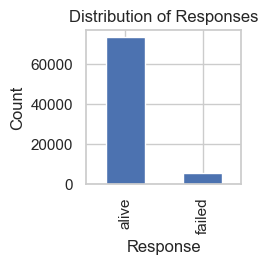

In [10]:
value_counts = df['Company Status'].value_counts()

plt.figure(figsize=(2, 2))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Responses')

# Show the plot
plt.show()

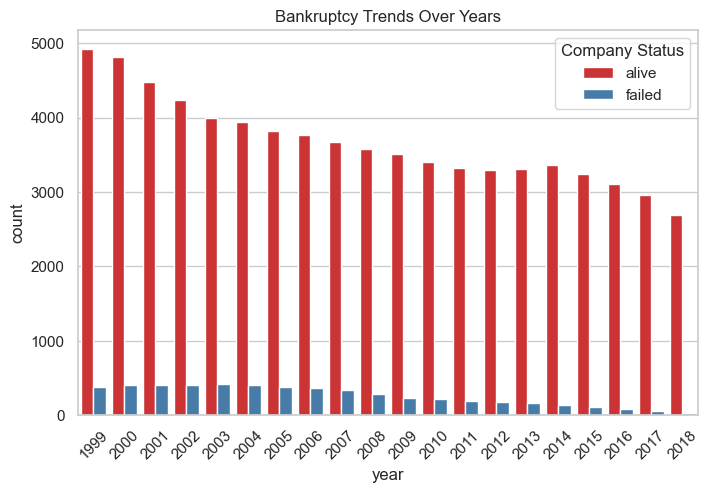

In [23]:

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="year", hue="Company Status", palette="Set1")
plt.title("Bankruptcy Trends Over Years")
plt.xticks(rotation=45)
plt.show()

# Data Preprocessing

In [8]:
X = df.drop(columns=["company_name", "Company Status"])
y = df["Company Status"].map({"alive": 0, "failed": 1}) 

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:

# Drop year for scaling
X_train_no_year = X_train.drop(columns=['year'])
X_test_no_year = X_test.drop(columns=['year'])

In [12]:
# Separate year column before scaling
X_train_year = X_train[['year']]
X_test_year = X_test[['year']]


In [9]:
minmax = MinMaxScaler()
X_train_mm = minmax.fit_transform(X_train)
X_test_mm = minmax.transform(X_test)

In [13]:
# Scale only the numeric columns (excluding year)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_year)
X_test_scaled = scaler.transform(X_test_no_year)

In [14]:
from imblearn.combine import SMOTEENN
smt = SMOTEENN(sampling_strategy="minority")
X_train_scaled, y_train = smt.fit_resample(X_train_scaled, y_train)

In [25]:
X_train_scaled.shape

(105431, 18)

<Axes: xlabel='Company Status'>

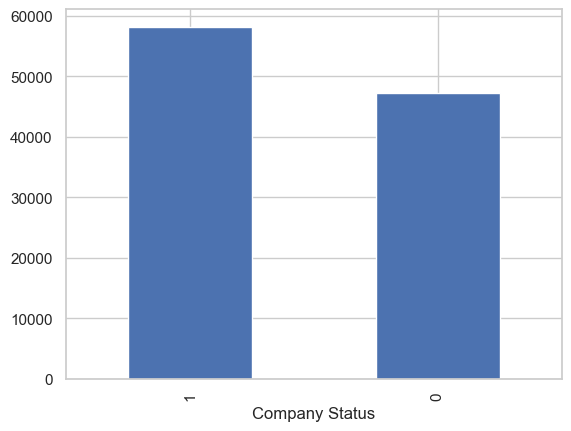

In [22]:
y_train.value_counts().plot.bar()

In [27]:
# Convert back to DataFrame with original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_no_year.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_no_year.columns, index=X_test.index)


In [28]:
# Add year column back
X_train_scaled['year'] = X_train_year
X_test_scaled['year'] = X_test_year

In [29]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [30]:
print("🔹 Training with Class Weights")
rf_weighted = RandomForestClassifier(random_state=42)
rf_weighted.fit(X_train_scaled, y_train)

🔹 Training with Class Weights


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred_weighted = rf_weighted.predict(X_test_scaled)
print("Classification Report (Class Weights):")
print(classification_report(y_test, y_pred_weighted))
print("ROC-AUC:", roc_auc_score(y_test, rf_weighted.predict_proba(X_test_scaled)[:,1]))

Classification Report (Class Weights):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     14693
           1       0.37      0.48      0.42      1044

    accuracy                           0.91     15737
   macro avg       0.67      0.71      0.68     15737
weighted avg       0.92      0.91      0.92     15737

ROC-AUC: 0.852915239957099


In [51]:
print("\n🔹 Training with SMOTETomek Resampling")
smt = SMOTETomek(random_state=42)
X_resampled, y_resampled = smt.fit_resample(X_train_scaled, y_train)


🔹 Training with SMOTETomek Resampling


In [53]:

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_resampled, y_resampled)

y_pred_smote = rf_smote.predict(X_test_scaled)
print("Classification Report (SMOTETomek):")
print(classification_report(y_test, y_pred_smote))
print(accuracy_score(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, rf_smote.predict_proba(X_test_scaled)[:,1]))


Classification Report (SMOTETomek):
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     14693
           1       0.36      0.56      0.44      1044

    accuracy                           0.91     15737
   macro avg       0.66      0.75      0.69     15737
weighted avg       0.93      0.91      0.91     15737

0.9050644976806252
ROC-AUC: 0.8716542894640841


,year,Current assets,Cost of goods sold,Depreciation and amortization,EBDITDA,Inventory,Net Income,Total Receivable,Market Value,Net Sales,Total Assets,Total Long-term Debt,EBIT,Gross Profit,Total Current Liabilitie,Retained Earnings,Total Revenue,Total Liabilities,Total Operating Expenses
55080,2018,65,125,6,16,46,5,13,17,199,141,64,10,74,37,-22,199,102,182
37401,2015,705,890,27,-141,11,-179,193,4384,1267,894,0,-169,376,334,-608,1267,386,1408
76050,2012,5,5,0,-4,0,-4,0,45,0,6,0,-4,-4,0,-10,0,0,5
76056,2018,179,141,9,-120,0,-203,4,293,21,624,223,-129,-120,61,-367,21,416,141
76705,2013,525,1762,96,206,81,-20,255,438,2102,1182,464,110,339,431,-245,2102,1046,1895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18264,2009,1003,974,101,395,360,302,366,2142,1890,3839,1192,294,915,337,1397,1890,2253,1494
39121,2001,140,302,247,359,61,100,29,706,1379,718,402,112,1077,411,-487,1379,832,1020
15610,2002,58,22,0,11,0,7,17,156,54,67,0,10,31,20,12,54,20,43
14333,2001,146,226,59,200,3,101,38,771,469,1964,854,141,242,85,743,469,1150,268


<Axes: >

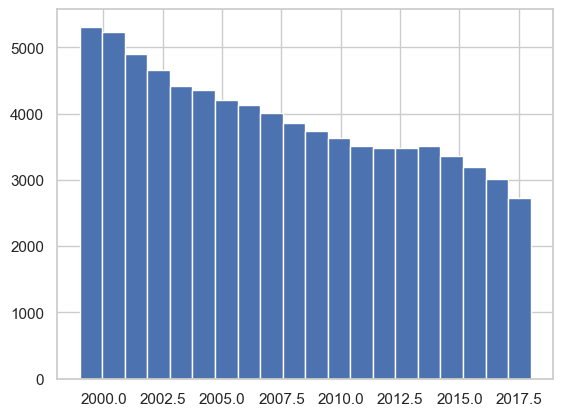

In [43]:
# checking distribution for age col
df['year'].hist(bins=20)

# HyperParameter Tuning

In [16]:
import optuna

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [18]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(),pruner=optuna.pruners.MedianPruner())  # We aim to maximize accuracy
study.optimize(objective, n_trials=10)  # Run 50 trials to find the best hyperparameters


[I 2025-08-24 00:34:09,952] A new study created in memory with name: no-name-7b43e8b0-83a8-4b4a-89e0-025462122654
[I 2025-08-24 00:36:26,838] Trial 0 finished with value: 0.9339105565495737 and parameters: {'n_estimators': 141, 'max_depth': 9}. Best is trial 0 with value: 0.9339105565495737.
[I 2025-08-24 00:37:49,628] Trial 1 finished with value: 0.9336563666358245 and parameters: {'n_estimators': 117, 'max_depth': 6}. Best is trial 0 with value: 0.9339105565495737.
[I 2025-08-24 00:39:11,490] Trial 2 finished with value: 0.9342441796282578 and parameters: {'n_estimators': 69, 'max_depth': 11}. Best is trial 2 with value: 0.9342441796282578.
[I 2025-08-24 00:41:45,823] Trial 3 finished with value: 0.9350226360024924 and parameters: {'n_estimators': 97, 'max_depth': 14}. Best is trial 3 with value: 0.9350226360024924.
[I 2025-08-24 00:44:37,085] Trial 4 finished with value: 0.9337516864337466 and parameters: {'n_estimators': 196, 'max_depth': 7}. Best is trial 3 with value: 0.935022636

In [19]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'n_estimators': 63, 'max_depth': 17}
Best trial accuracy: 0.9359758529114978


In [20]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_n_estimators,state
0,0,0.933911,2025-08-24 00:34:09.955575,2025-08-24 00:36:26.838966,0 days 00:02:16.883391,9,141,COMPLETE
1,1,0.933656,2025-08-24 00:36:26.838966,2025-08-24 00:37:49.628194,0 days 00:01:22.789228,6,117,COMPLETE
2,2,0.934244,2025-08-24 00:37:49.631151,2025-08-24 00:39:11.490949,0 days 00:01:21.859798,11,69,COMPLETE
3,3,0.935023,2025-08-24 00:39:11.492255,2025-08-24 00:41:45.823362,0 days 00:02:34.331107,14,97,COMPLETE
4,4,0.933752,2025-08-24 00:41:45.826398,2025-08-24 00:44:37.085888,0 days 00:02:51.259490,7,196,COMPLETE
5,5,0.934149,2025-08-24 00:44:37.087145,2025-08-24 00:48:04.247117,0 days 00:03:27.159972,11,179,COMPLETE
6,6,0.935976,2025-08-24 00:48:04.250204,2025-08-24 00:49:28.928664,0 days 00:01:24.678460,17,63,COMPLETE
7,7,0.934371,2025-08-24 00:49:28.931543,2025-08-24 00:51:57.894751,0 days 00:02:28.963208,12,137,COMPLETE
8,8,0.935626,2025-08-24 00:51:57.894751,2025-08-24 00:55:32.365155,0 days 00:03:34.470404,16,159,COMPLETE
9,9,0.933656,2025-08-24 00:55:32.367015,2025-08-24 00:56:10.460478,0 days 00:00:38.093463,3,107,COMPLETE


In [21]:
study.trials_dataframe()['params_n_estimators'].value_counts()

params_n_estimators
141    1
117    1
69     1
97     1
196    1
179    1
63     1
137    1
159    1
107    1
Name: count, dtype: int64

In [22]:
study.trials_dataframe().groupby('params_max_depth')['value'].mean()

params_max_depth
3     0.933656
6     0.933656
7     0.933752
9     0.933911
11    0.934197
12    0.934371
14    0.935023
16    0.935626
17    0.935976
Name: value, dtype: float64

In [23]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [24]:
# 1. Optimization History
plot_optimization_history(study).show()

In [25]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

In [27]:
# 4. Contour Plot
plot_contour(study).show()

In [28]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

In [30]:
# 3. Slice Plot
plot_slice(study).show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna

In [ ]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['RandomForest', 'GradientBoosting']) #SVM

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

In [ ]:
# Create a study and optimize it using TPESampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

In [34]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np


# Define the objective function for XGBoost
def objective2(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
    dtest = xgb.DMatrix(X_test_scaled, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective2, n_trials=5)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")


[I 2025-08-24 00:59:49,612] A new study created in memory with name: no-name-9eb841e9-5338-424f-bdbc-81d3165d0ac3


[0]	train-mlogloss:0.96898	eval-mlogloss:0.96909
[1]	train-mlogloss:0.86297	eval-mlogloss:0.86320
[2]	train-mlogloss:0.77558	eval-mlogloss:0.77595
[3]	train-mlogloss:0.70187	eval-mlogloss:0.70229
[4]	train-mlogloss:0.63951	eval-mlogloss:0.64012
[5]	train-mlogloss:0.58608	eval-mlogloss:0.58680
[6]	train-mlogloss:0.54034	eval-mlogloss:0.54123
[7]	train-mlogloss:0.50083	eval-mlogloss:0.50193
[8]	train-mlogloss:0.46680	eval-mlogloss:0.46810
[9]	train-mlogloss:0.43703	eval-mlogloss:0.43842
[10]	train-mlogloss:0.41094	eval-mlogloss:0.41249
[11]	train-mlogloss:0.38836	eval-mlogloss:0.39014
[12]	train-mlogloss:0.36875	eval-mlogloss:0.37064
[13]	train-mlogloss:0.35179	eval-mlogloss:0.35394
[14]	train-mlogloss:0.33677	eval-mlogloss:0.33908
[15]	train-mlogloss:0.32378	eval-mlogloss:0.32626
[16]	train-mlogloss:0.31204	eval-mlogloss:0.31471
[17]	train-mlogloss:0.30190	eval-mlogloss:0.30474
[18]	train-mlogloss:0.29277	eval-mlogloss:0.29583
[19]	train-mlogloss:0.28483	eval-mlogloss:0.28800
[20]	train

[I 2025-08-24 01:00:08,026] Trial 0 finished with value: 0.9374721992755926 and parameters: {'lambda': 0.04601216857502081, 'alpha': 6.793547571951454e-07, 'eta': 0.10995437156088168, 'gamma': 4.453679309719781e-07, 'max_depth': 5, 'min_child_weight': 2, 'subsample': 0.5549556539974605, 'colsample_bytree': 0.417939218950247}. Best is trial 0 with value: 0.9374721992755926.


[0]	train-mlogloss:0.95532	eval-mlogloss:0.95546
[1]	train-mlogloss:0.84117	eval-mlogloss:0.84135
[2]	train-mlogloss:0.74831	eval-mlogloss:0.74855
[3]	train-mlogloss:0.67174	eval-mlogloss:0.67208
[4]	train-mlogloss:0.60781	eval-mlogloss:0.60823
[5]	train-mlogloss:0.55407	eval-mlogloss:0.55454
[6]	train-mlogloss:0.50865	eval-mlogloss:0.50916
[7]	train-mlogloss:0.47018	eval-mlogloss:0.47076
[8]	train-mlogloss:0.43736	eval-mlogloss:0.43799
[9]	train-mlogloss:0.40919	eval-mlogloss:0.40990
[10]	train-mlogloss:0.38506	eval-mlogloss:0.38590
[11]	train-mlogloss:0.36439	eval-mlogloss:0.36531
[12]	train-mlogloss:0.34658	eval-mlogloss:0.34758
[13]	train-mlogloss:0.33123	eval-mlogloss:0.33233
[14]	train-mlogloss:0.31793	eval-mlogloss:0.31911
[15]	train-mlogloss:0.30635	eval-mlogloss:0.30766
[16]	train-mlogloss:0.29630	eval-mlogloss:0.29774
[17]	train-mlogloss:0.28761	eval-mlogloss:0.28910
[18]	train-mlogloss:0.28002	eval-mlogloss:0.28160
[19]	train-mlogloss:0.27328	eval-mlogloss:0.27492
[20]	train

[I 2025-08-24 01:00:23,810] Trial 1 finished with value: 0.9367096651204169 and parameters: {'lambda': 2.748831618110211e-07, 'alpha': 0.0008419604280022277, 'eta': 0.12211528171119078, 'gamma': 0.08202681137169854, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.9823020333568744, 'colsample_bytree': 0.8176675399418407}. Best is trial 0 with value: 0.9374721992755926.


[0]	train-mlogloss:0.83075	eval-mlogloss:0.83254
[1]	train-mlogloss:0.65835	eval-mlogloss:0.66183
[2]	train-mlogloss:0.53868	eval-mlogloss:0.54404


[I 2025-08-24 01:00:24,539] Trial 2 pruned. Trial was pruned at iteration 2.


[0]	train-mlogloss:0.91022	eval-mlogloss:0.91117
[1]	train-mlogloss:0.76993	eval-mlogloss:0.77246
[2]	train-mlogloss:0.66228	eval-mlogloss:0.66583


[I 2025-08-24 01:00:25,234] Trial 3 pruned. Trial was pruned at iteration 2.


[0]	train-mlogloss:0.85868	eval-mlogloss:0.85964
[1]	train-mlogloss:0.69689	eval-mlogloss:0.69875


[I 2025-08-24 01:00:25,698] Trial 4 pruned. Trial was pruned at iteration 2.


Best trial: {'lambda': 0.04601216857502081, 'alpha': 6.793547571951454e-07, 'eta': 0.10995437156088168, 'gamma': 4.453679309719781e-07, 'max_depth': 5, 'min_child_weight': 2, 'subsample': 0.5549556539974605, 'colsample_bytree': 0.417939218950247}
Best accuracy: 0.9374721992755926


In [35]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()